---
Kaiming uniform initialization, SGD with learning rate = 0.001

In [27]:
import concept_generalization
from concept_generalization import *
importlib.reload(concept_generalization)
from concept_generalization import *

In [29]:
center_list = [[0,0,0], [0,0,1], [0,1,0], [1,0,0]]
var_list = [ [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01] ]]*4
test_centers = [[0,0,0], [0,0,1], [0,1,0], [1,0,0], [0,1,1], [1,0,1], [1,1,0], [1,1,1]]
test_vars = [ [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01] ]]*8
hidd_list = [128, 2048]
n_hiddDim = len(hidd_list)
# defaults
n_test = 20
k, lo, hi, step = 10, 100, 110, 10
loss_n = range(lo, hi, step)

In [30]:
eval_list_lr = [[] for _ in range(n_hiddDim)]  # list of test evaluations
losses_list_lr = [[] for _ in range(n_hiddDim)]    # list of training loss histories
test_points_list_lr = [[] for _ in range(n_hiddDim)]    # list of test points
weights_list_lr = [[] for _ in range(n_hiddDim)]   # list of learned model weights
norms_list_lr = [[] for _ in range(n_hiddDim)]     # list of norms of learned model weights


In [32]:
hidden_dim = [hidd_list[0]]
evals_lr, test_points_lr, losses_lr, weights_lr, norms_lr = collect_clusterPredictions(hidden_dim, center_list, var_list, test_centers, test_vars, opt='SGD', lr=0.001, use_init='he')
eval_list_lr[0] = evals_lr
losses_list_lr[0] = losses_lr
test_points_list_lr[0] = test_points_lr
weights_list_lr[0] = weights_lr
norms_list_lr[0] = norms_lr

on iteration 0  of k= 10
Epoch 0: Loss = 3.1005
Epoch 1000: Loss = 0.0021
Epoch 2000: Loss = 0.0011
Epoch 3000: Loss = 0.0008
Epoch 4000: Loss = 0.0006
Epoch 5000: Loss = 0.0005
Epoch 6000: Loss = 0.0005
Epoch 7000: Loss = 0.0004
Epoch 8000: Loss = 0.0004
Epoch 9000: Loss = 0.0004
batch loss = tensor(9.4766e-05, grad_fn=<MseLossBackward0>)
random sample loss = tensor(4.2797e-05, grad_fn=<MseLossBackward0>)
batch loss = tensor(0.0001, grad_fn=<MseLossBackward0>)
random sample loss = tensor(0.0001, grad_fn=<MseLossBackward0>)
batch loss = tensor(0.0001, grad_fn=<MseLossBackward0>)
random sample loss = tensor(8.4829e-05, grad_fn=<MseLossBackward0>)
batch loss = tensor(0.0002, grad_fn=<MseLossBackward0>)
random sample loss = tensor(1.9509e-05, grad_fn=<MseLossBackward0>)
final epoch loss= tensor(0.0003, grad_fn=<AddBackward0>)
on iteration 1  of k= 10
Epoch 0: Loss = 2.7819
Epoch 1000: Loss = 0.0019
Epoch 2000: Loss = 0.0010
Epoch 3000: Loss = 0.0007
Epoch 4000: Loss = 0.0006
Epoch 5000: L

In [ ]:
hidden_dim = [hidd_list[1]]
evals_lr, test_points_lr, losses_lr, weights_lr, norms_lr = collect_clusterPredictions(hidden_dim, center_list, var_list, test_centers, test_vars, lr=0.01, use_init='he')
eval_list_lr[1] = evals_lr
losses_list_lr[1] = losses_lr
test_points_list_lr[1] = test_points_lr
weights_list_lr[1] = weights_lr
norms_list_lr[1] = norms_lr

on iteration 0  of k= 10


KeyboardInterrupt: 

In [ ]:
for i in range(k):
    for hd in range(n_hiddDim):
        for layer in range(2):
            torch.save({'linear.weight': weights_list[hd][0][i][2*layer], 'linear.bias': weights_list[hd][0][i][2*layer+1]}, 
                   "dim=%s_layer=" % hidd_list[hd] + str(layer) + "_k="+str(i)+".pth")

NameError: name 'weights_list' is not defined

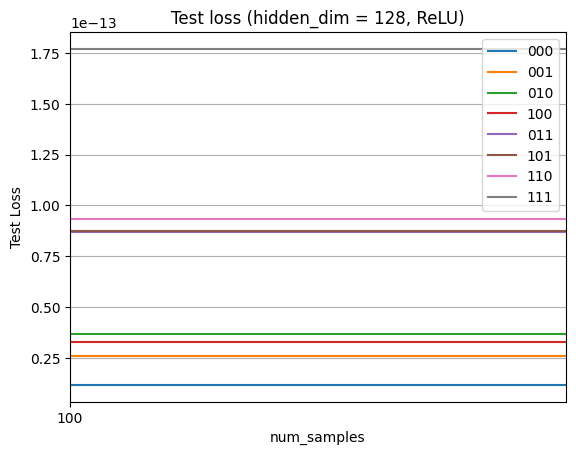

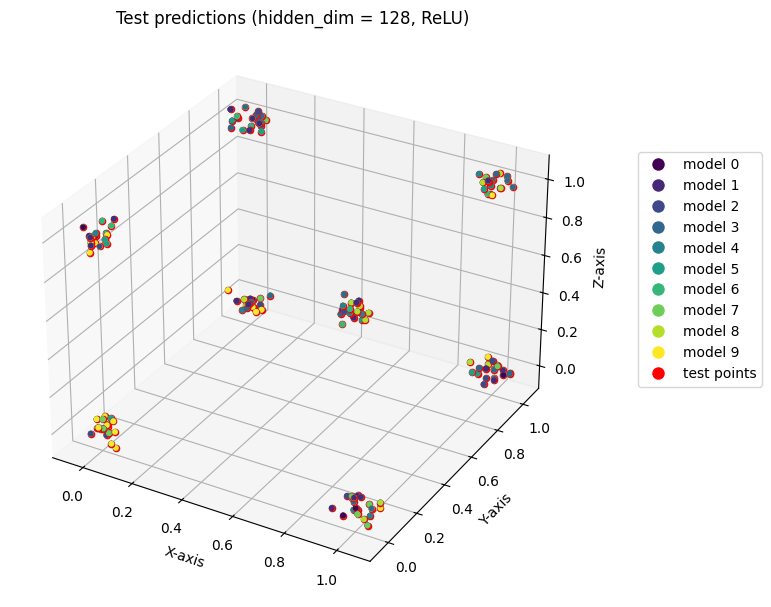

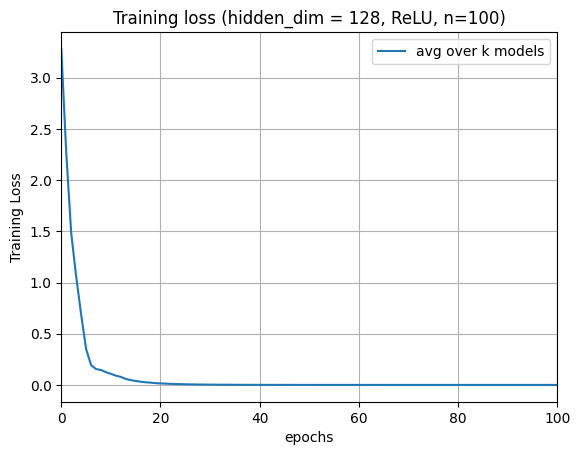

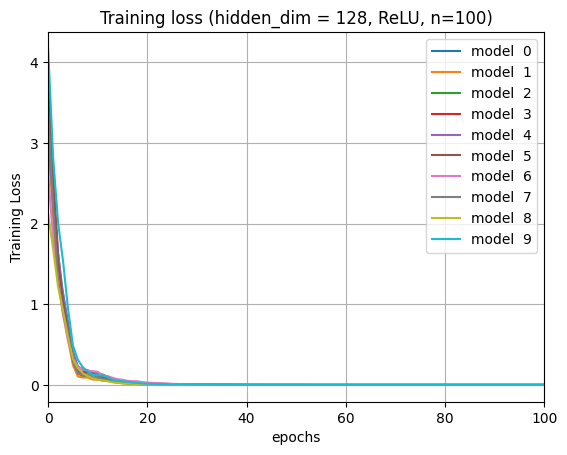

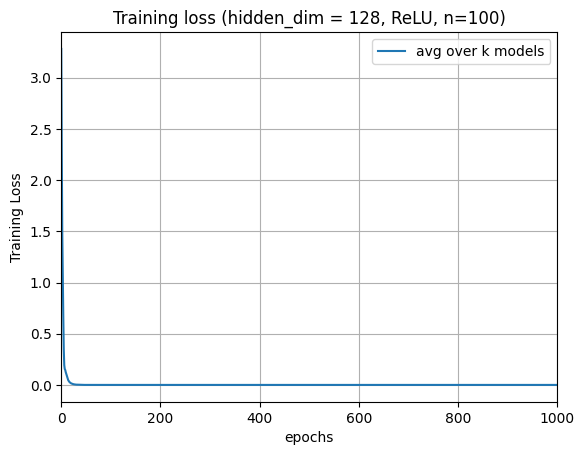

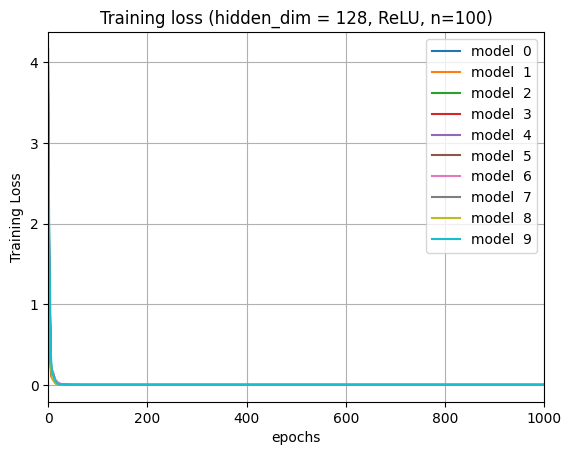

Final training loss for trial 0: 1.6463144459884574e-13
Final training loss for trial 1: 1.020080812760794e-13
Final training loss for trial 2: 1.2044186110146508e-13
Final training loss for trial 3: 1.2789048926863458e-13
Final training loss for trial 4: 1.012571747098772e-13
Final training loss for trial 5: 9.326819542653398e-14
Final training loss for trial 6: 1.0307446018128878e-13
Final training loss for trial 7: 1.1399636897153117e-13
Final training loss for trial 8: 1.3065913504134788e-13
Final training loss for trial 9: 9.282195644706379e-14


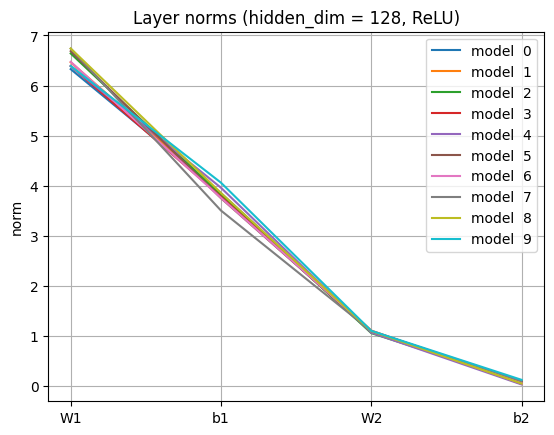

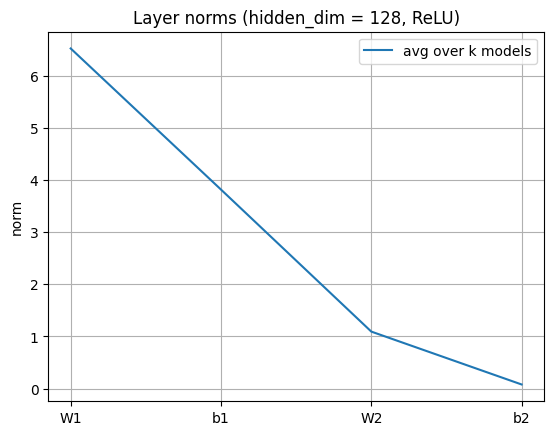

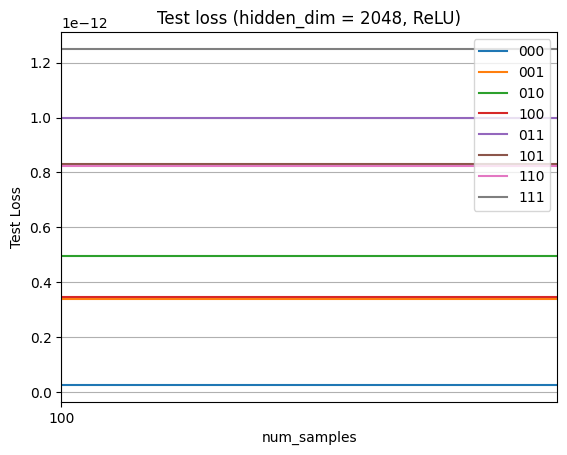

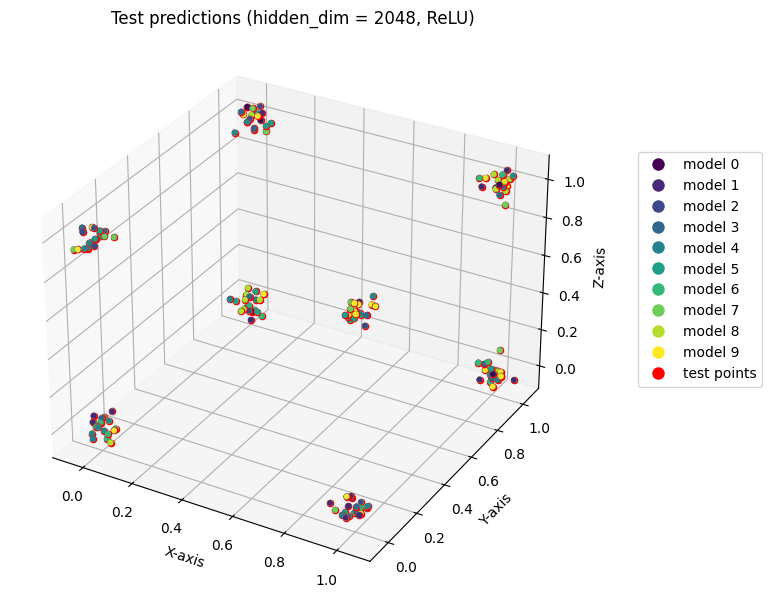

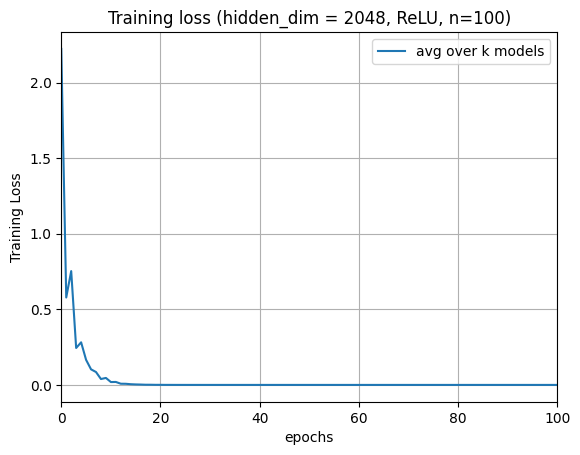

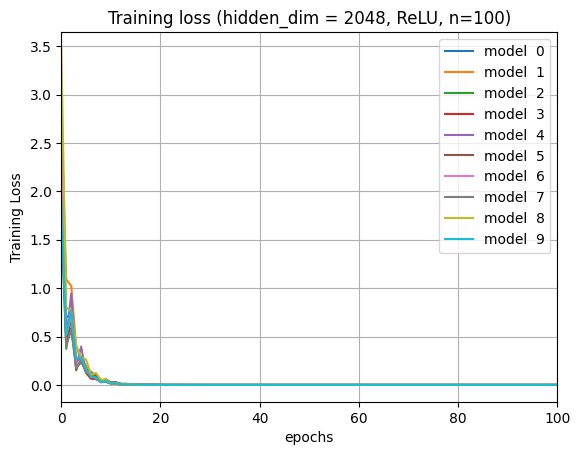

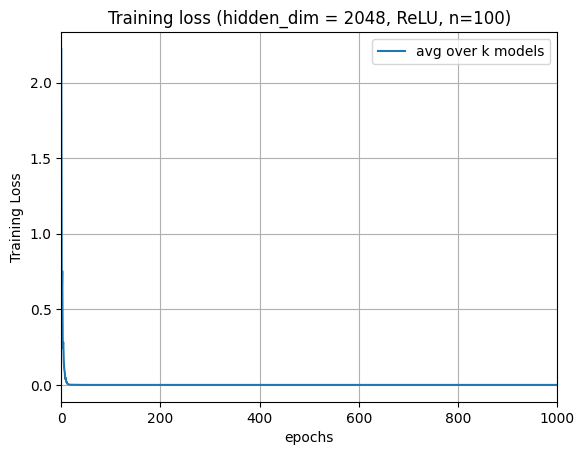

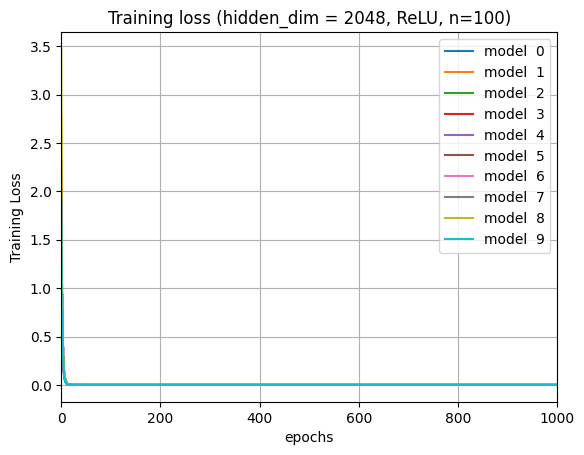

Final training loss for trial 0: 1.118262763204897e-12
Final training loss for trial 1: 1.1695883790543288e-12
Final training loss for trial 2: 1.17658267568925e-12
Final training loss for trial 3: 1.4001003725535102e-12
Final training loss for trial 4: 1.0454928210060915e-12
Final training loss for trial 5: 1.2564908965714827e-12
Final training loss for trial 6: 1.4378493241960083e-12
Final training loss for trial 7: 1.642097346770885e-12
Final training loss for trial 8: 1.4618685222848177e-12
Final training loss for trial 9: 1.956313800191567e-12


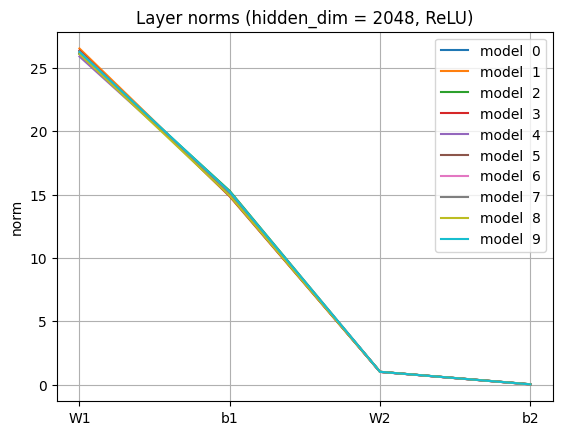

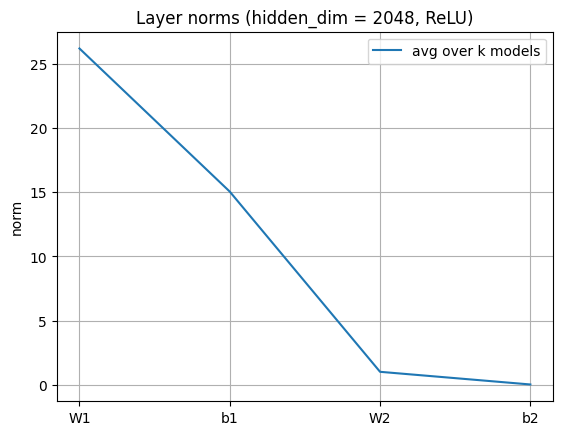

In [ ]:
testLoss_list_lr = [[] for _ in range(n_hiddDim)]

for i in range(n_hiddDim):
    hidden_dim = hidd_list[i]
    testLoss_lr = compute_clusterLoss(eval_list_lr[i], test_points_list_lr[i], test_centers)
    plot_clusterTestLoss(np.concatenate((testLoss_lr, testLoss_lr), axis=1), test_centers, hidden_dim)
    testLoss_list_lr[i] = np.reshape(testLoss_lr, (8))
    
    scatter_testPredictions(eval_list_lr[i], test_points_list_lr[i], hidden_dim, test_ids=range(8))
    
    plot_list = range(len(loss_n))
    plot_trainingLoss(np.mean(losses_list_lr[i][0], axis=0, keepdims=True), loss_n, plot_list, hidden_dim, epochs=100)
    plot_trainingLoss(losses_list_lr[i], loss_n, plot_list, hidden_dim, trials=range(k), epochs=100)
    plot_trainingLoss(np.mean(losses_list_lr[i][0], axis=0, keepdims=True), loss_n, plot_list, hidden_dim, epochs=1000)
    plot_trainingLoss(losses_list_lr[i], loss_n, plot_list, hidden_dim, trials=range(k), epochs=1000)
    for j in range(k):
        print("Final training loss for trial " + str(j) + ": " + str(losses_list_lr[i][0][j][-1]))

    plot_norms(norms_list_lr[i], hidden_dim)
    plot_norms(np.mean(norms_list_lr[i], axis=1, keepdims=True), hidden_dim)

---
without gradient clipping

on iteration 0  of k= 10
on iteration 1  of k= 10
on iteration 2  of k= 10
on iteration 3  of k= 10
on iteration 4  of k= 10
on iteration 5  of k= 10
on iteration 6  of k= 10
on iteration 7  of k= 10
on iteration 8  of k= 10
on iteration 9  of k= 10
on iteration 0  of k= 10
on iteration 1  of k= 10
on iteration 2  of k= 10
on iteration 3  of k= 10
on iteration 4  of k= 10
on iteration 5  of k= 10
on iteration 6  of k= 10
on iteration 7  of k= 10
on iteration 8  of k= 10
on iteration 9  of k= 10


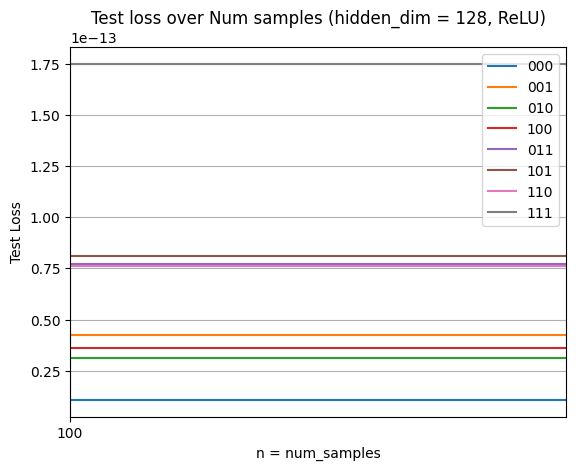

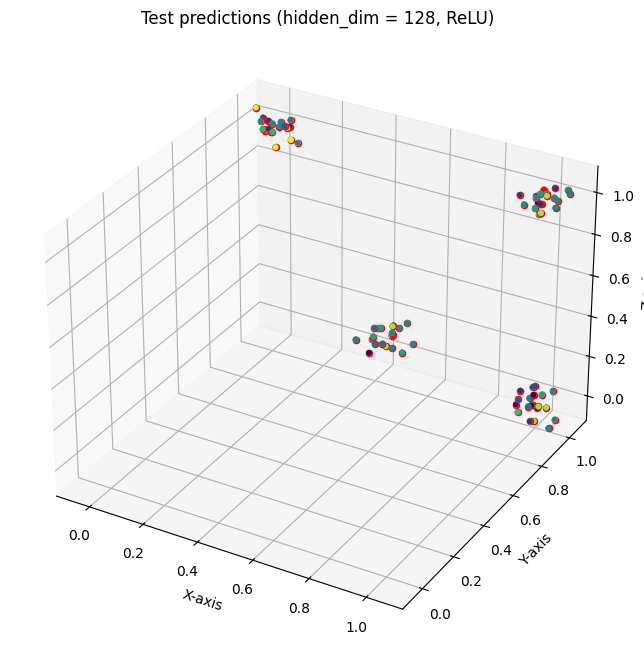

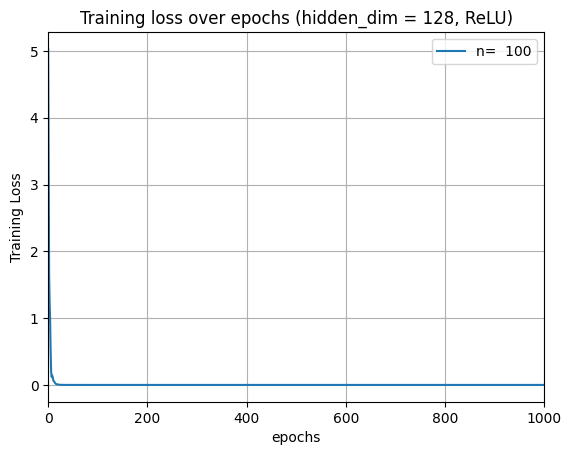

7.65629692891373e-14 7.754116190014215e-14


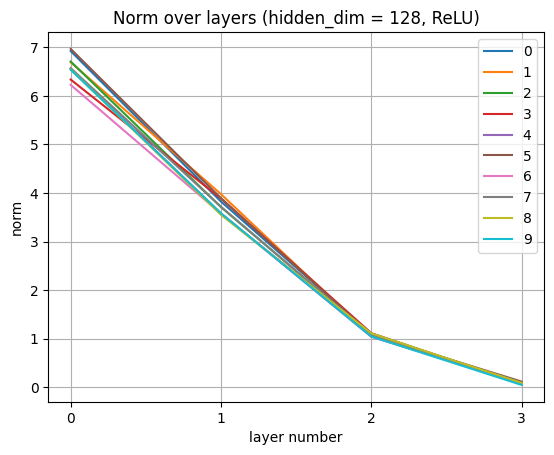

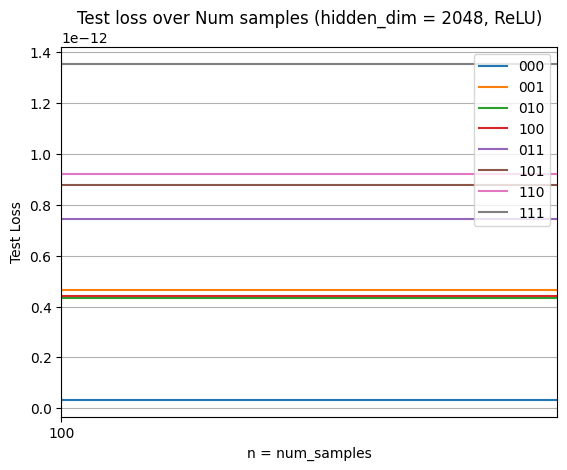

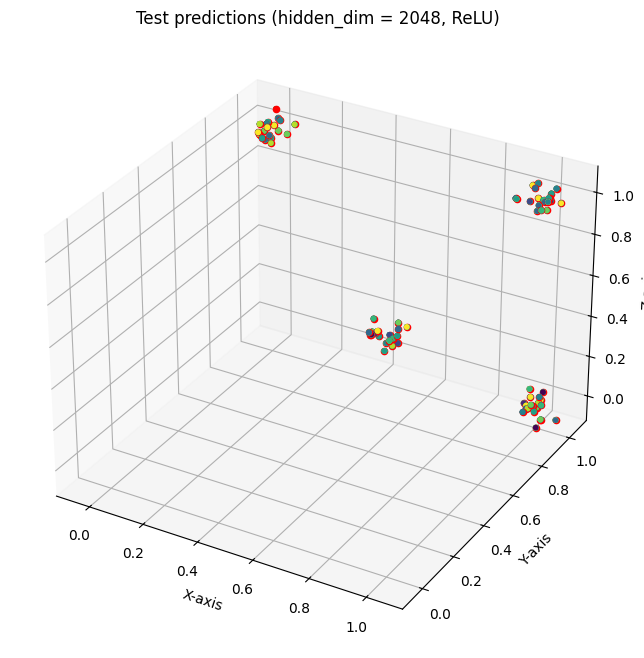

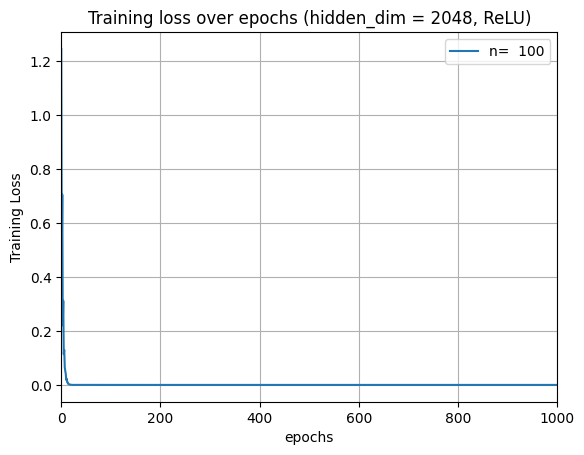

7.65629692891373e-14 7.754116190014215e-14


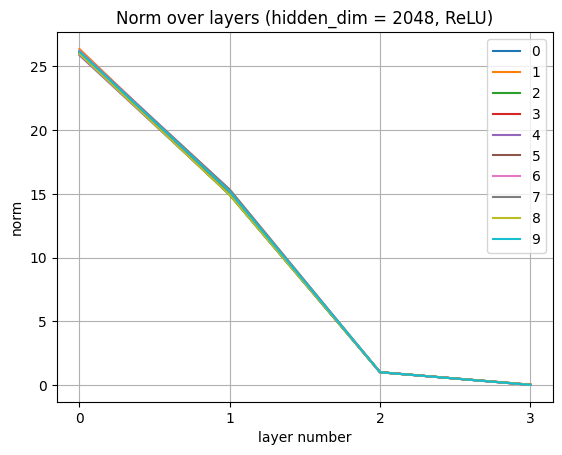

In [42]:
import concept_generalization
from concept_generalization import *
importlib.reload(concept_generalization)
from concept_generalization import *
center_list = [[0,0,0], [0,0,1], [0,1,0], [1,0,0]]
var_list = [ [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01] ]]*4
test_centers = [[0,0,0], [0,0,1], [0,1,0], [1,0,0], [0,1,1], [1,0,1], [1,1,0], [1,1,1]]
test_vars = [ [[0.001, 0, 0], [0, 0.001, 0], [0, 0, 0.001] ]]*8
hidd_list = [128, 2048]
n_hiddDim = len(hidd_list)
# defaults
n_test = 20
k, lo, hi, step = 10, 100, 110, 10
loss_n = range(lo, hi, step)
eval_list_lr_noclip = [[] for _ in range(n_hiddDim)]  # list of test evaluations
losses_list_lr_noclip = [[] for _ in range(n_hiddDim)]    # list of training loss histories
test_points_list_lr_noclip = [[] for _ in range(n_hiddDim)]    # list of test points
weights_list_lr_noclip = [[] for _ in range(n_hiddDim)]   # list of learned model weights
norms_list_lr_noclip = [[] for _ in range(n_hiddDim)]     # list of norms of learned model weights

hidden_dim = [hidd_list[0]]
evals_lr_noclip, test_points_lr_noclip, losses_lr_noclip, weights_lr_noclip, norms_lr_noclip = collect_clusterPredictions(hidden_dim, center_list, var_list, test_centers, test_vars, lr=0.001, use_init='he')
eval_list_lr_noclip[0] = evals_lr_noclip
losses_list_lr_noclip[0] = losses_lr_noclip
test_points_list_lr_noclip[0] = test_points_lr_noclip
weights_list_lr_noclip[0] = weights_lr_noclip
norms_list_lr_noclip[0] = norms_lr_noclip
hidden_dim = [hidd_list[1]]
evals_lr_noclip, test_points_lr_noclip, losses_lr_noclip, weights_lr_noclip, norms_lr_noclip = collect_clusterPredictions(hidden_dim, center_list, var_list, test_centers, test_vars, lr=0.001, use_init='he')
eval_list_lr_noclip[1] = evals_lr_noclip
losses_list_lr_noclip[1] = losses_lr_noclip
test_points_list_lr_noclip[1] = test_points_lr_noclip
weights_list_lr_noclip[1] = weights_lr_noclip
norms_list_lr_noclip[1] = norms_lr_noclip
testLoss_list_lr_noclip = [[] for _ in range(n_hiddDim)]

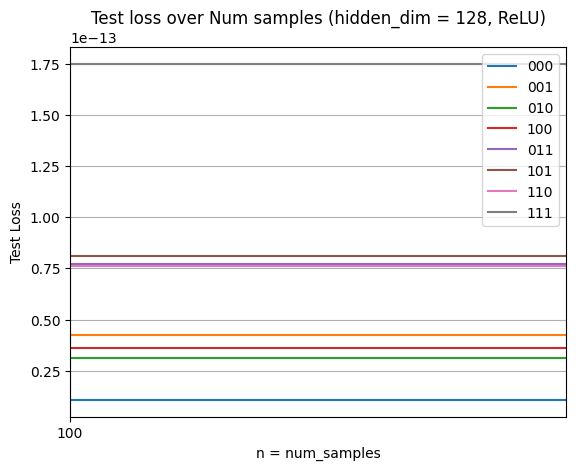

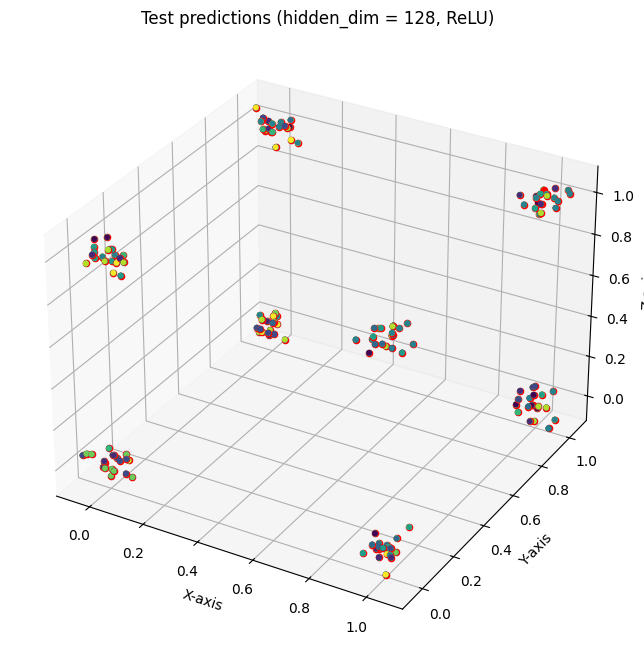

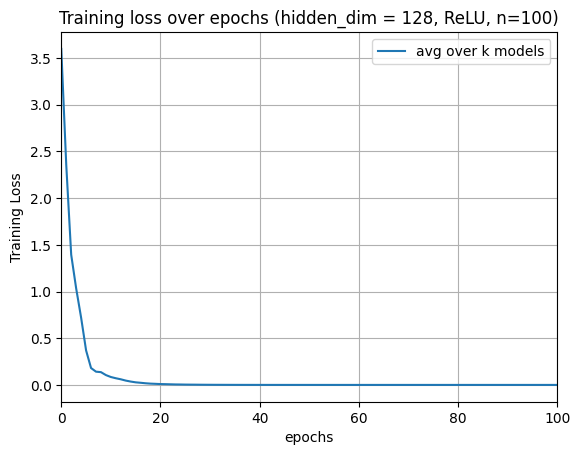

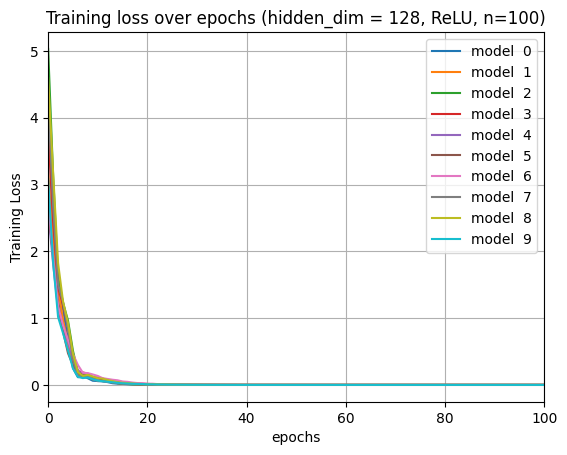

Final training loss for trial 0: 7.754116190014215e-14
Final training loss for trial 1: 1.2160629423471452e-13
Final training loss for trial 2: 1.1601750816829254e-13
Final training loss for trial 3: 9.909259048349831e-14
Final training loss for trial 4: 1.711489260589668e-13
Final training loss for trial 5: 9.358146886801009e-14
Final training loss for trial 6: 1.5360349914206838e-13
Final training loss for trial 7: 1.0617980663273335e-13
Final training loss for trial 8: 1.2130705104697673e-13
Final training loss for trial 9: 1.5285496935031617e-13


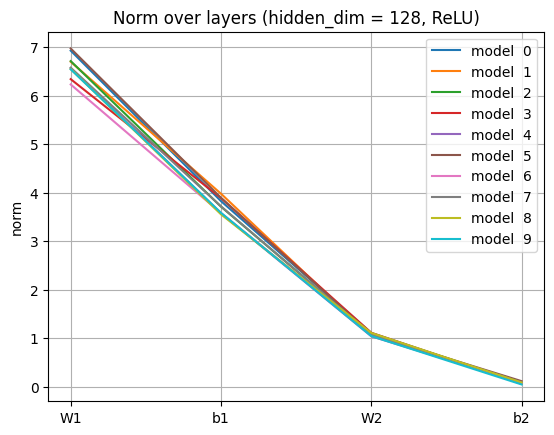

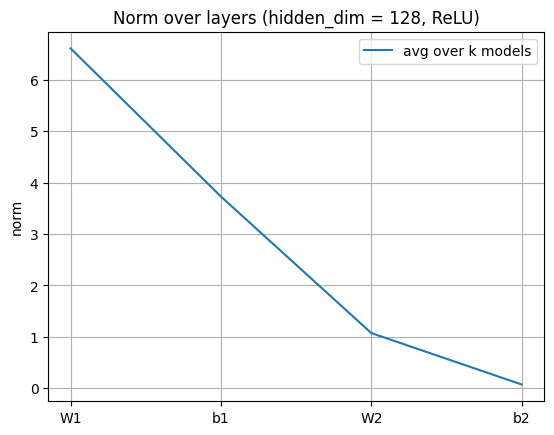

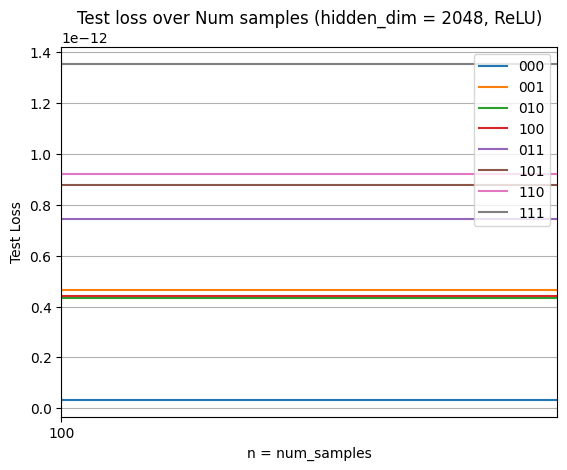

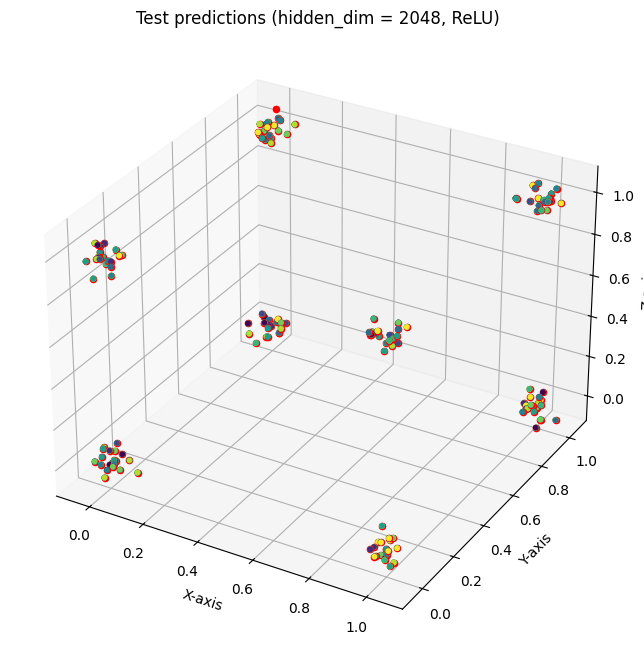

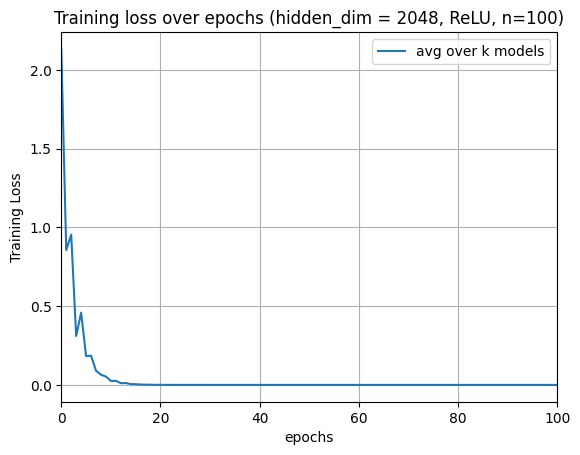

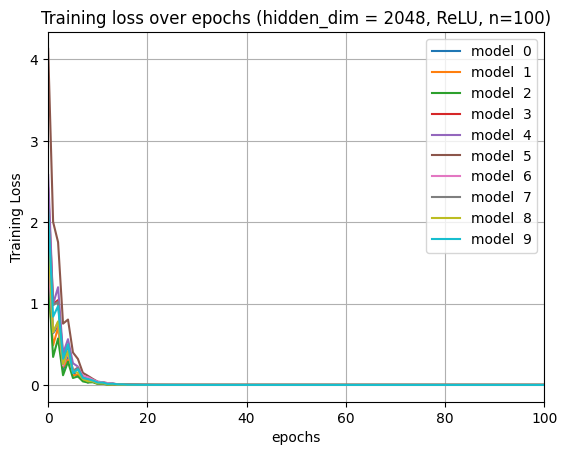

Final training loss for trial 0: 1.5204109943701277e-12
Final training loss for trial 1: 1.451021323494589e-12
Final training loss for trial 2: 1.3198144291869107e-12
Final training loss for trial 3: 1.369126681602037e-12
Final training loss for trial 4: 1.4356481769454282e-12
Final training loss for trial 5: 1.3545245925328936e-12
Final training loss for trial 6: 1.8524373929327403e-12
Final training loss for trial 7: 1.7147703341904158e-12
Final training loss for trial 8: 1.5162698841723193e-12
Final training loss for trial 9: 1.443310992639904e-12


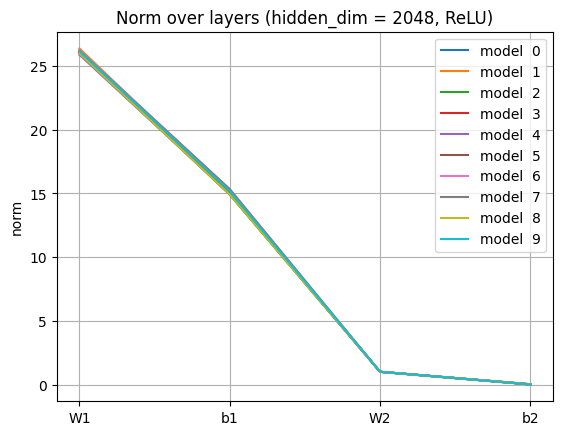

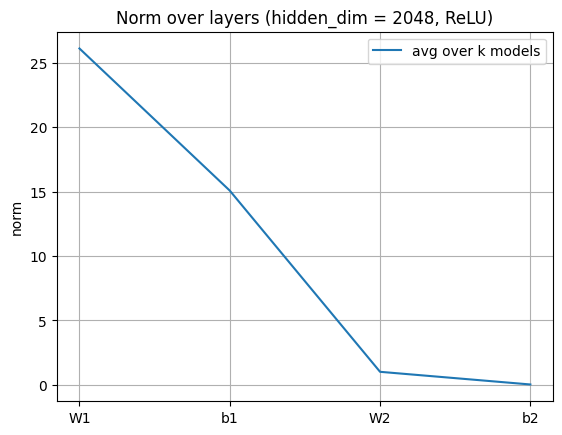

In [111]:
for i in range(n_hiddDim):
    hidden_dim = hidd_list[i]
    testLoss_lr_noclip = compute_clusterLoss(eval_list_lr_noclip[i], test_points_list_lr_noclip[i], test_centers)
    plot_clusterTestLoss(np.concatenate((testLoss_lr_noclip, testLoss_lr_noclip), axis=1), test_centers, hidden_dim)
    testLoss_list_lr_noclip[i] = np.reshape(testLoss_lr_noclip, (8))
    
    scatter_testPredictions(eval_list_lr_noclip[i], test_points_list_lr_noclip[i], hidden_dim, test_ids=range(8))
    
    plot_list = range(len(loss_n))
    plot_trainingLoss(np.mean(losses_list_lr_noclip[i][0], axis=0, keepdims=True), loss_n, plot_list, hidden_dim, epochs=100)
    plot_trainingLoss(losses_list_lr_noclip[i], loss_n, plot_list, hidden_dim, trials=range(k), epochs=100)
    for j in range(k):
        print("Final training loss for trial " + str(j) + ": " + str(losses_list_lr_noclip[i][0][j][-1]))

    plot_norms(norms_list_lr_noclip[i], hidden_dim)
    plot_norms(np.mean(norms_list_lr_noclip[i], axis=1, keepdims=True), hidden_dim)

on iteration 0  of k= 10
on iteration 1  of k= 10
on iteration 2  of k= 10
on iteration 3  of k= 10
on iteration 4  of k= 10
on iteration 5  of k= 10
on iteration 6  of k= 10
on iteration 7  of k= 10
on iteration 8  of k= 10
on iteration 9  of k= 10


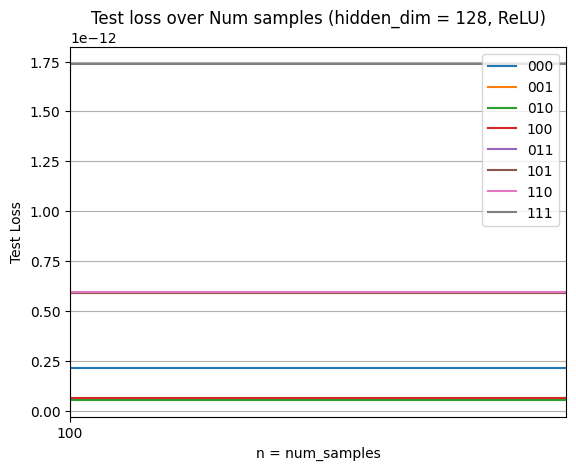

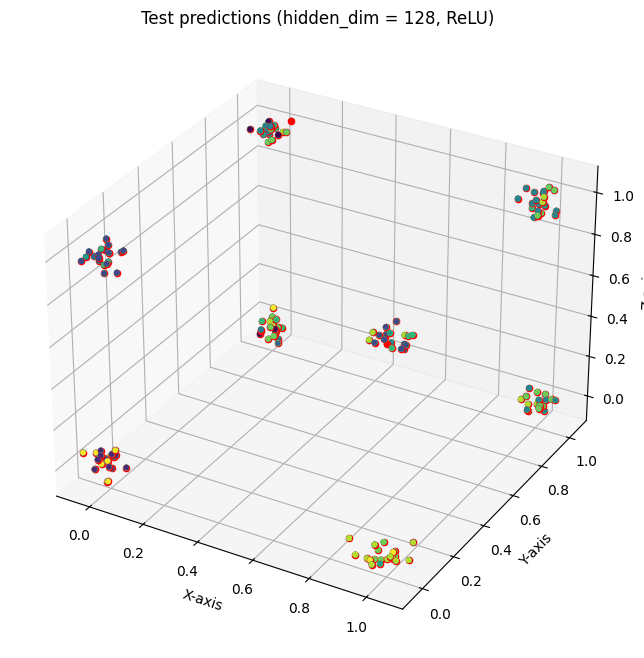

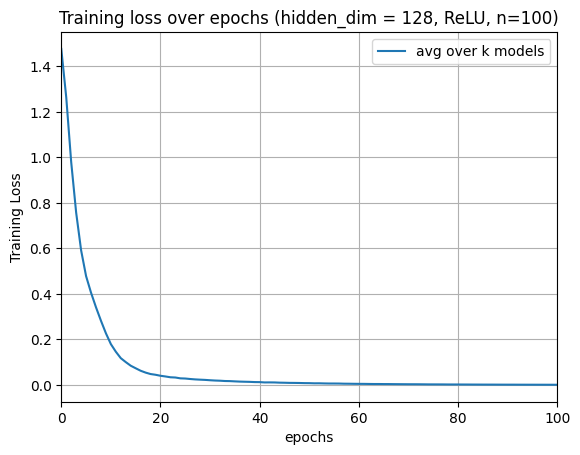

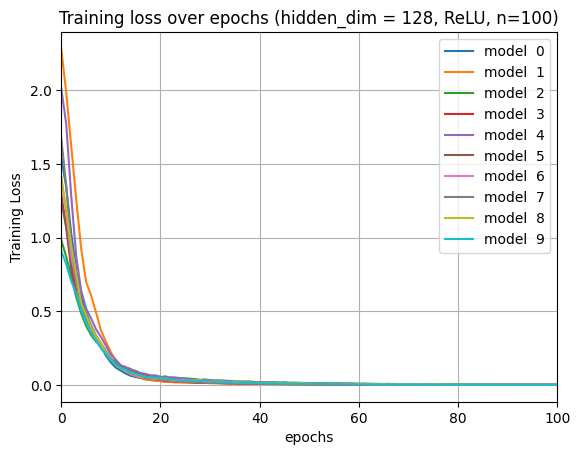

Final training loss for trial 0: 1.2923252149400072e-13
Final training loss for trial 1: 7.731432986499923e-14
Final training loss for trial 2: 1.2090136800502107e-13
Final training loss for trial 3: 8.12985136568016e-14
Final training loss for trial 4: 1.2861500398226623e-13
Final training loss for trial 5: 1.603067383156541e-13
Final training loss for trial 6: 2.276397725376779e-13
Final training loss for trial 7: 9.254333681752575e-14
Final training loss for trial 8: 2.2712917430080942e-13
Final training loss for trial 9: 1.8968119718139331e-13


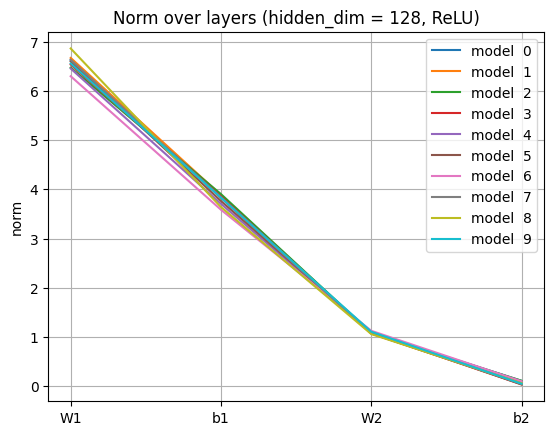

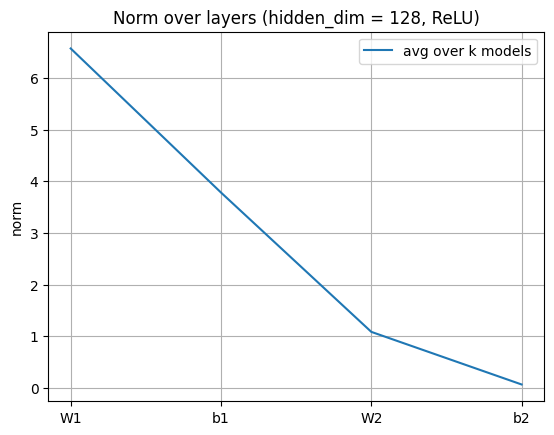

In [106]:
import concept_generalization
from concept_generalization import *
importlib.reload(concept_generalization)
from concept_generalization import *
center_list = [[0,0,0], [0,0,1], [0,1,0], [1,0,0]]
var_list = [ [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01] ]]*4
test_centers = [[0,0,0], [0,0,1], [0,1,0], [1,0,0], [0,1,1], [1,0,1], [1,1,0], [1,1,1]]
test_vars = [ [[0.001, 0, 0], [0, 0.001, 0], [0, 0, 0.001] ]]*8
hidd_list = [128]
n_hiddDim = len(hidd_list)
# defaults
n_test = 20
k, lo, hi, step = 10, 100, 110, 10
loss_n = range(lo, hi, step)
eval_list_lr_debug = [[] for _ in range(n_hiddDim)]  # list of test evaluations
losses_list_lr_debug = [[] for _ in range(n_hiddDim)]    # list of training loss histories
test_points_list_lr_debug = [[] for _ in range(n_hiddDim)]    # list of test points
weights_list_lr_debug = [[] for _ in range(n_hiddDim)]   # list of learned model weights
norms_list_lr_debug = [[] for _ in range(n_hiddDim)]     # list of norms of learned model weights

hidden_dim = [hidd_list[0]]
evals_lr_debug, test_points_lr_debug, losses_lr_debug, weights_lr_debug, norms_lr_debug = collect_clusterPredictions(hidden_dim, center_list, var_list, test_centers, test_vars, lr=0.001, use_init='he')
eval_list_lr_debug[0] = evals_lr_debug
losses_list_lr_debug[0] = losses_lr_debug
test_points_list_lr_debug[0] = test_points_lr_debug
weights_list_lr_debug[0] = weights_lr_debug
norms_list_lr_debug[0] = norms_lr_debug

testLoss_list_lr_debug = [[] for _ in range(n_hiddDim)]
for i in range(n_hiddDim):
    hidden_dim = hidd_list[i]
    testLoss_lr_debug = compute_clusterLoss(eval_list_lr_debug[i], test_points_list_lr_debug[i], test_centers)
    plot_clusterTestLoss(np.concatenate((testLoss_lr_debug, testLoss_lr_debug), axis=1), test_centers, hidden_dim)
    testLoss_list_lr_debug[i] = np.reshape(testLoss_lr_debug, (8))
    
    scatter_testPredictions(eval_list_lr_debug[i], test_points_list_lr_debug[i], hidden_dim, test_ids=range(8))
    
    plot_list = range(len(loss_n))
    plot_trainingLoss(np.mean(losses_list_lr_debug[0][0], axis=0, keepdims=True), loss_n, plot_list, hidden_dim, epochs=100)
    plot_trainingLoss(losses_list_lr_debug[i], loss_n, plot_list, hidden_dim, trials=range(k), epochs=100)
    for j in range(k):
        print("Final training loss for trial " + str(j) + ": " + str(losses_list_lr_debug[i][0][j][-1]))

    plot_norms(norms_list_lr_debug[i], hidden_dim)
    plot_norms(np.mean(norms_list_lr_debug[i], axis=1, keepdims=True), hidden_dim)